## 1. Importação de Bibliotecas

In [33]:
# Importação de bibliotecas necessárias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path
import warnings
from collections import defaultdict

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configuração do tamanho das figuras
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Bibliotecas carregadas com sucesso")

Bibliotecas carregadas com sucesso


## 2. Carregamento da Estrutura do Dataset

In [25]:
# Definição do caminho do dataset
data_path = Path("E:/pyhon/trabalho_compl_v2/data/raw/framed_and_centralized_v4_method_b")

# Verificação da existência do caminho
if not data_path.exists():
    print(f"ERRO: Caminho não encontrado: {data_path}")
else:
    print(f"Dataset localizado em: {data_path.absolute()}")

# Listagem das classes (diretórios) no dataset
classes = [d.name for d in data_path.iterdir() if d.is_dir()]
classes.sort()

print(f"\nTotal de classes encontradas: {len(classes)}")
print("\nClasses disponíveis:")
for i, class_name in enumerate(classes, 1):
    print(f"   {i:2d}. {class_name}")

# Criação de dicionário para armazenar informações sobre cada classe
class_info = {}

# ESCOLHA AQUI: Quais imagens considerar?
# Todos os arquivos têm extensão .jpg (minúscula)
FILTRO = ['.jpg']

print(f"\nExplorando estrutura das classes (usando filtro: {FILTRO}):")
for class_name in classes:
    class_path = data_path / class_name
    if class_path.is_dir():
        # Contagem de arquivos de imagem na classe
        all_files = list(class_path.iterdir())
        image_files = [f for f in all_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        
        class_info[class_name] = {
            'path': class_path,
            'count': len(image_files),
            'files': image_files
        }
        
        print(f"   {class_name}: {len(image_files)} imagens")

total_images = sum([info['count'] for info in class_info.values()])
print(f"\nTotal de imagens no dataset: {total_images:,}")

Dataset localizado em: E:\pyhon\trabalho_compl_v2\data\raw\framed_and_centralized_v4_method_b

Total de classes encontradas: 14

Classes disponíveis:
    1. Agglutinated
    2. Brittle
    3. Compartmentalized_Brown
    4. Compartmentalized_PartiallyPurple
    5. Compartmentalized_Purple
    6. Compartmentalized_Slaty
    7. Compartmentalized_White
    8. Flattened
    9. Moldered
   10. Plated_Brown
   11. Plated_PartiallyPurple
   12. Plated_Purple
   13. Plated_Slaty
   14. Plated_White

Explorando estrutura das classes (usando filtro: ['.jpg']):
   Agglutinated: 100 imagens
   Brittle: 100 imagens
   Compartmentalized_Brown: 100 imagens
   Compartmentalized_PartiallyPurple: 100 imagens
   Compartmentalized_Purple: 100 imagens
   Compartmentalized_Slaty: 100 imagens
   Compartmentalized_White: 100 imagens
   Flattened: 100 imagens
   Moldered: 100 imagens
   Plated_Brown: 100 imagens
   Plated_PartiallyPurple: 100 imagens
   Plated_Purple: 100 imagens
   Plated_Slaty: 100 imagens
  

## 3. Análise da Distribuição por Classes

In [27]:
# Criação de DataFrame com a distribuição de classes
class_distribution = pd.DataFrame([
    {'Classe': class_name, 'Quantidade': info['count']} 
    for class_name, info in class_info.items()
])

class_distribution = class_distribution.sort_values('Quantidade', ascending=False)

# Estatísticas descritivas
print("ESTATÍSTICAS DA DISTRIBUIÇÃO DE CLASSES")
print("="*50)
print(f"Total de imagens: {class_distribution['Quantidade'].sum():,}")
print(f"Média por classe: {class_distribution['Quantidade'].mean():.1f}")
print(f"Mediana por classe: {class_distribution['Quantidade'].median():.1f}")
print(f"Desvio padrão: {class_distribution['Quantidade'].std():.1f}")
print(f"Classe com mais imagens: {class_distribution.iloc[0]['Classe']} ({class_distribution.iloc[0]['Quantidade']} imagens)")
print(f"Classe com menos imagens: {class_distribution.iloc[-1]['Classe']} ({class_distribution.iloc[-1]['Quantidade']} imagens)")

# Cálculo de porcentagens
class_distribution['Porcentagem'] = (class_distribution['Quantidade'] / total_images * 100)

print(f"\nDISTRIBUIÇÃO DETALHADA")
print("="*50)
print(class_distribution.to_string(index=False, float_format='%.1f'))

ESTATÍSTICAS DA DISTRIBUIÇÃO DE CLASSES
Total de imagens: 1,400
Média por classe: 100.0
Mediana por classe: 100.0
Desvio padrão: 0.0
Classe com mais imagens: Agglutinated (100 imagens)
Classe com menos imagens: Plated_White (100 imagens)

DISTRIBUIÇÃO DETALHADA
                           Classe  Quantidade  Porcentagem
                     Agglutinated         100          7.1
                          Brittle         100          7.1
          Compartmentalized_Brown         100          7.1
Compartmentalized_PartiallyPurple         100          7.1
         Compartmentalized_Purple         100          7.1
          Compartmentalized_Slaty         100          7.1
          Compartmentalized_White         100          7.1
                        Flattened         100          7.1
                         Moldered         100          7.1
                     Plated_Brown         100          7.1
           Plated_PartiallyPurple         100          7.1
                    Plated_Pur

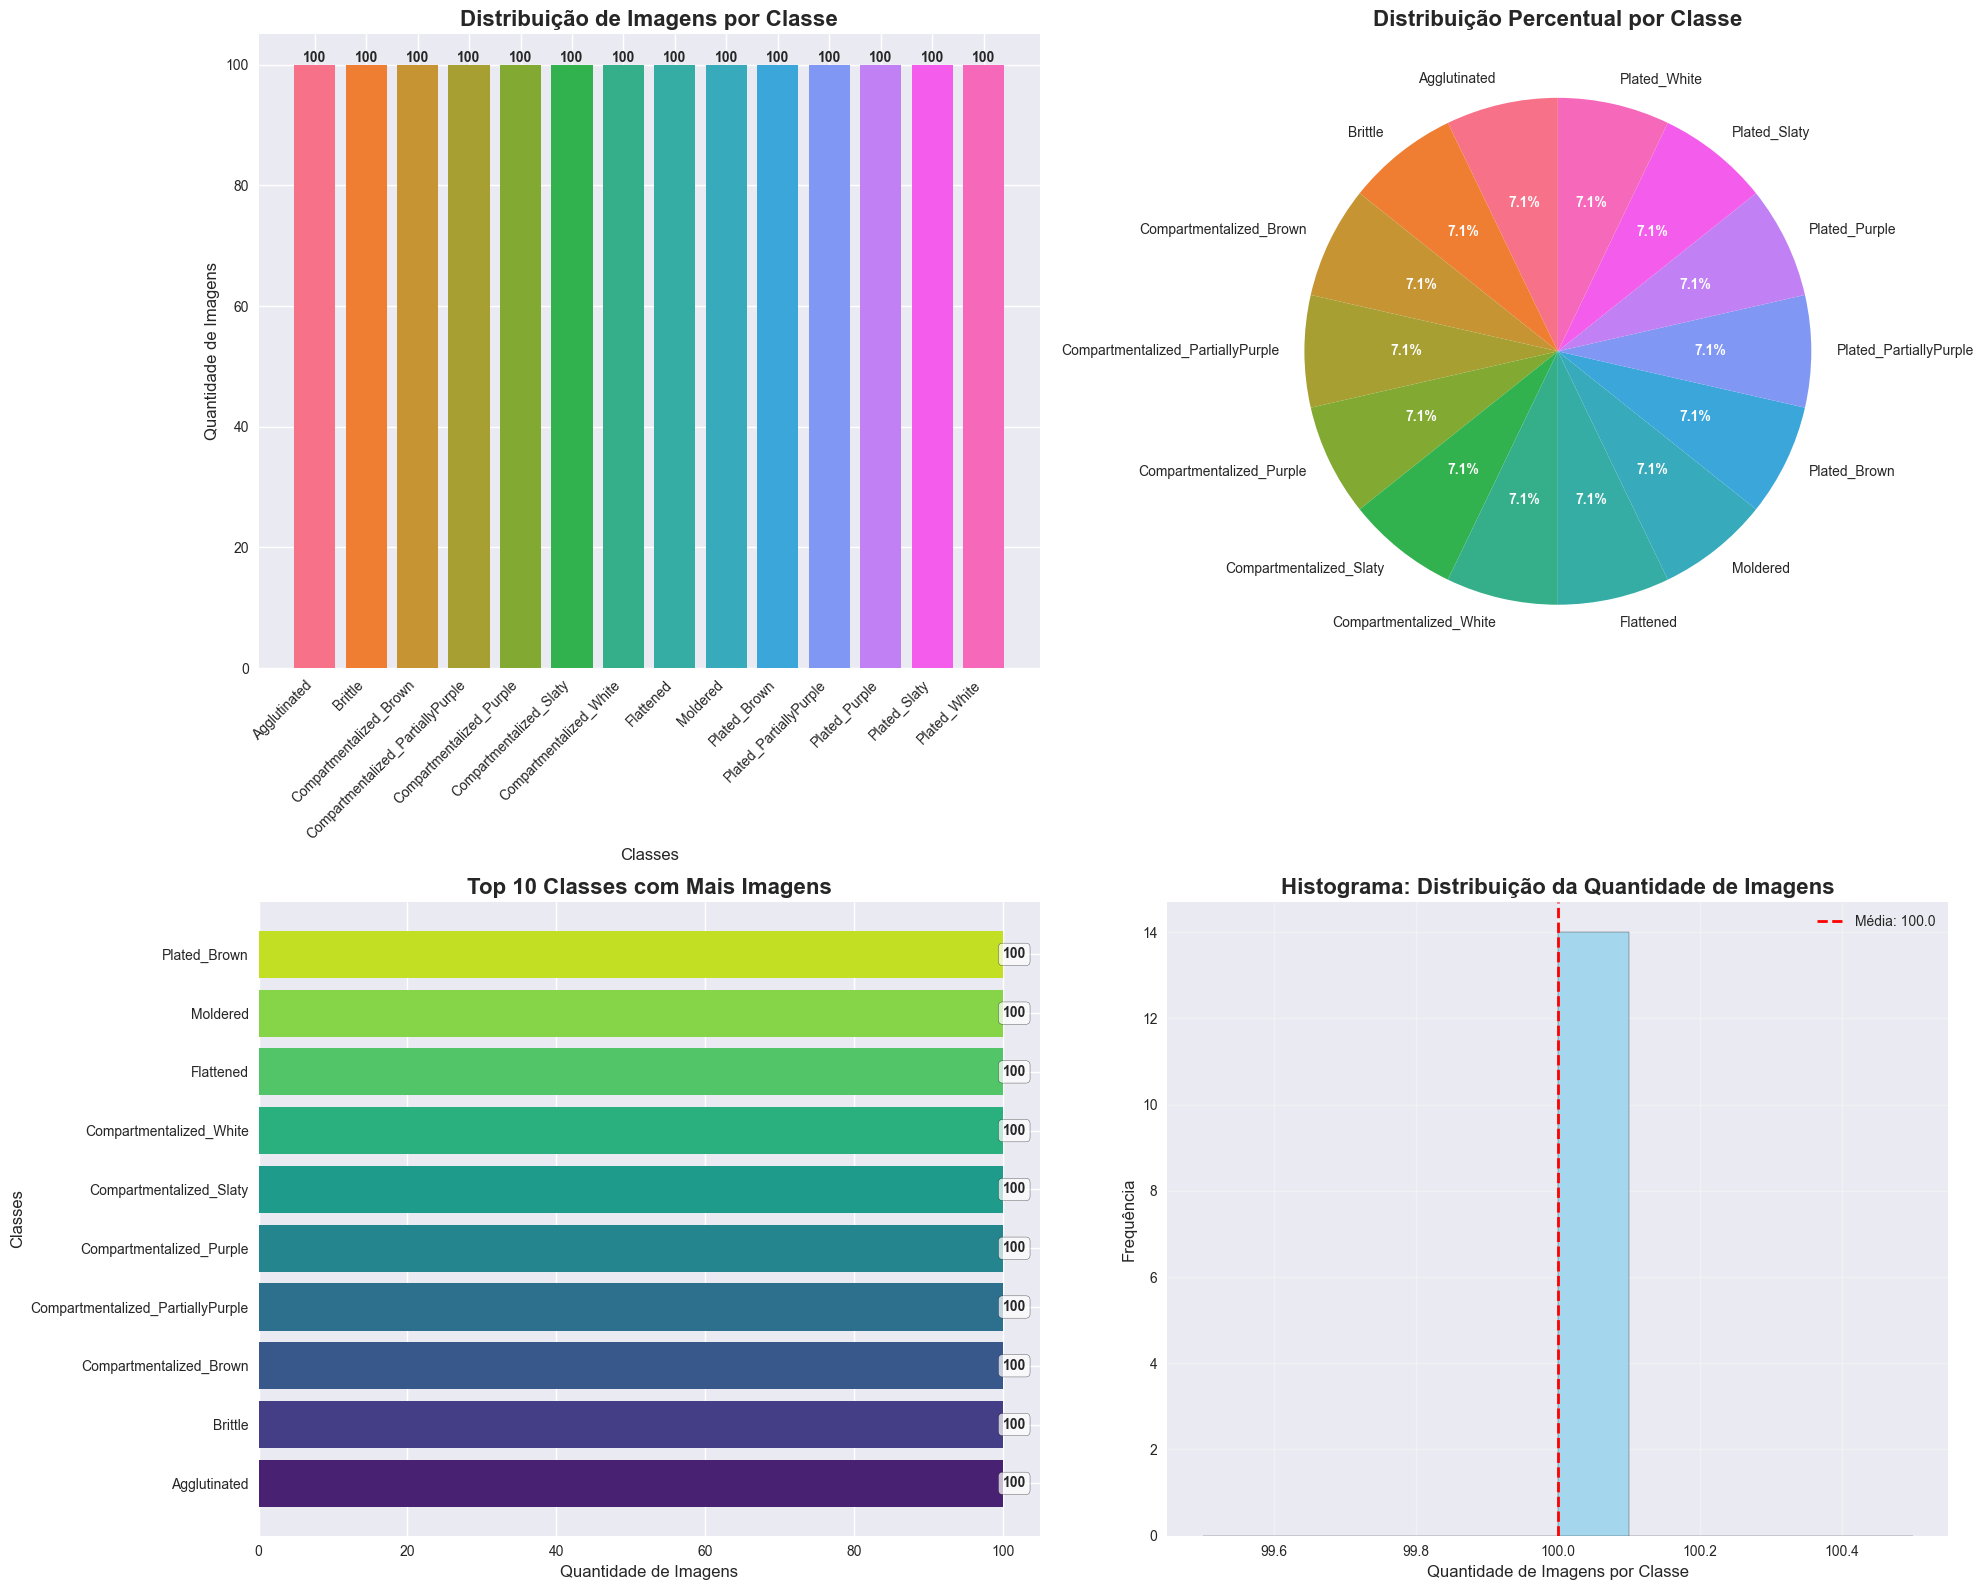


ANÁLISE DE DESBALANCEAMENTO
Ratio de desbalanceamento: 1.00
Dataset relativamente balanceado


In [28]:
# Visualizações da distribuição de classes
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1. Gráfico de barras - Quantidade por classe
bars = ax1.bar(range(len(class_distribution)), class_distribution['Quantidade'], 
               color=sns.color_palette("husl", len(class_distribution)))
ax1.set_title('Distribuição de Imagens por Classe', fontsize=16, fontweight='bold')
ax1.set_xlabel('Classes', fontsize=12)
ax1.set_ylabel('Quantidade de Imagens', fontsize=12)
ax1.set_xticks(range(len(class_distribution)))
ax1.set_xticklabels(class_distribution['Classe'], rotation=45, ha='right')

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

# 2. Gráfico de pizza
wedges, texts, autotexts = ax2.pie(class_distribution['Quantidade'], 
                                   labels=class_distribution['Classe'],
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=sns.color_palette("husl", len(class_distribution)))
ax2.set_title('Distribuição Percentual por Classe', fontsize=16, fontweight='bold')

# Melhorar legibilidade do gráfico de pizza
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Gráfico de barras horizontal - Top 10
top_10 = class_distribution.head(10)
bars_h = ax3.barh(range(len(top_10)), top_10['Quantidade'], 
                  color=sns.color_palette("viridis", len(top_10)))
ax3.set_title('Top 10 Classes com Mais Imagens', fontsize=16, fontweight='bold')
ax3.set_xlabel('Quantidade de Imagens', fontsize=12)
ax3.set_ylabel('Classes', fontsize=12)
ax3.set_yticks(range(len(top_10)))
ax3.set_yticklabels(top_10['Classe'])

# Adicionar valores nas barras horizontais
for i, bar in enumerate(bars_h):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}',
             ha='left', va='center', fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# 4. Histograma da distribuição
ax4.hist(class_distribution['Quantidade'], bins=10, edgecolor='black', alpha=0.7,
         color='skyblue')
ax4.set_title('Histograma: Distribuição da Quantidade de Imagens', fontsize=16, fontweight='bold')
ax4.set_xlabel('Quantidade de Imagens por Classe', fontsize=12)
ax4.set_ylabel('Frequência', fontsize=12)
ax4.grid(True, alpha=0.3)

# Adicionar linha vertical para a média
mean_val = class_distribution['Quantidade'].mean()
ax4.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
           label=f'Média: {mean_val:.1f}')
ax4.legend()

plt.tight_layout()
plt.show()

# Análise de desbalanceamento
max_count = class_distribution['Quantidade'].max()
min_count = class_distribution['Quantidade'].min()
imbalance_ratio = max_count / min_count

print(f"\nANÁLISE DE DESBALANCEAMENTO")
print("="*50)
print(f"Ratio de desbalanceamento: {imbalance_ratio:.2f}")
if imbalance_ratio > 2.0:
    print("AVISO: Dataset apresenta desbalanceamento significativo")
else:
    print("Dataset relativamente balanceado")

## 4. Análise de Formato e Propriedades das Imagens

In [29]:
# Função para análise de propriedades das imagens
def analyze_image_properties(image_path):
    """Analisar propriedades de uma imagem"""
    try:
        # Carregamento da imagem com PIL
        with Image.open(image_path) as img:
            width, height = img.size
            format_info = img.format
            mode = img.mode
            
        # Tamanho do arquivo
        file_size = os.path.getsize(image_path) / (1024)  # KB
        
        return {
            'width': width,
            'height': height,
            'format': format_info,
            'mode': mode,
            'file_size_kb': file_size,
            'aspect_ratio': width / height,
            'total_pixels': width * height,
            'status': 'OK'
        }
    except Exception as e:
        return {
            'width': None,
            'height': None,
            'format': None,
            'mode': None,
            'file_size_kb': None,
            'aspect_ratio': None,
            'total_pixels': None,
            'status': f'ERROR: {str(e)}'
        }

# Análise de amostra de imagens de cada classe para otimização de performance
print("Analisando propriedades das imagens...")
print("(Processando amostra de 10 imagens por classe para otimização)")

image_properties = []
sample_size = 10  # Número de imagens por classe para análise

for class_name, info in class_info.items():
    print(f"   Processando classe: {class_name}")
    
    # Seleção de amostra de imagens da classe
    sample_files = info['files'][:sample_size] if len(info['files']) >= sample_size else info['files']
    
    for img_path in sample_files:
        props = analyze_image_properties(img_path)
        props['class'] = class_name
        props['filename'] = img_path.name
        image_properties.append(props)

# Conversão para DataFrame
df_props = pd.DataFrame(image_properties)

# Remoção de imagens com erro
valid_images = df_props[df_props['status'] == 'OK'].copy()
error_images = df_props[df_props['status'] != 'OK']

if len(error_images) > 0:
    print(f"AVISO: {len(error_images)} imagens com erro encontradas")
    print(error_images[['class', 'filename', 'status']].to_string(index=False))

print(f"\n{len(valid_images)} imagens analisadas com sucesso")

Analisando propriedades das imagens...
(Processando amostra de 10 imagens por classe para otimização)
   Processando classe: Agglutinated
   Processando classe: Brittle
   Processando classe: Compartmentalized_Brown
   Processando classe: Compartmentalized_PartiallyPurple
   Processando classe: Compartmentalized_Purple
   Processando classe: Compartmentalized_Slaty
   Processando classe: Compartmentalized_White
   Processando classe: Flattened
   Processando classe: Moldered
   Processando classe: Plated_Brown
   Processando classe: Plated_PartiallyPurple
   Processando classe: Plated_Purple
   Processando classe: Plated_Slaty
   Processando classe: Plated_White

140 imagens analisadas com sucesso


RESUMO DAS PROPRIEDADES DAS IMAGENS
Número de imagens analisadas: 140
Formatos encontrados: {'JPEG': 140}
Modos de cor encontrados: {'RGB': 140}

DIMENSÕES
Largura - Média: 4320.0px, Min: 4320px, Max: 4320px
Altura - Média: 3240.0px, Min: 3240px, Max: 3240px
Aspect Ratio - Média: 1.33, Min: 1.33, Max: 1.33

TAMANHOS DE ARQUIVO
Tamanho médio: 413.4 KB
Tamanho mínimo: 301.1 KB
Tamanho máximo: 573.5 KB
Tamanho total da amostra: 57874.4 KB


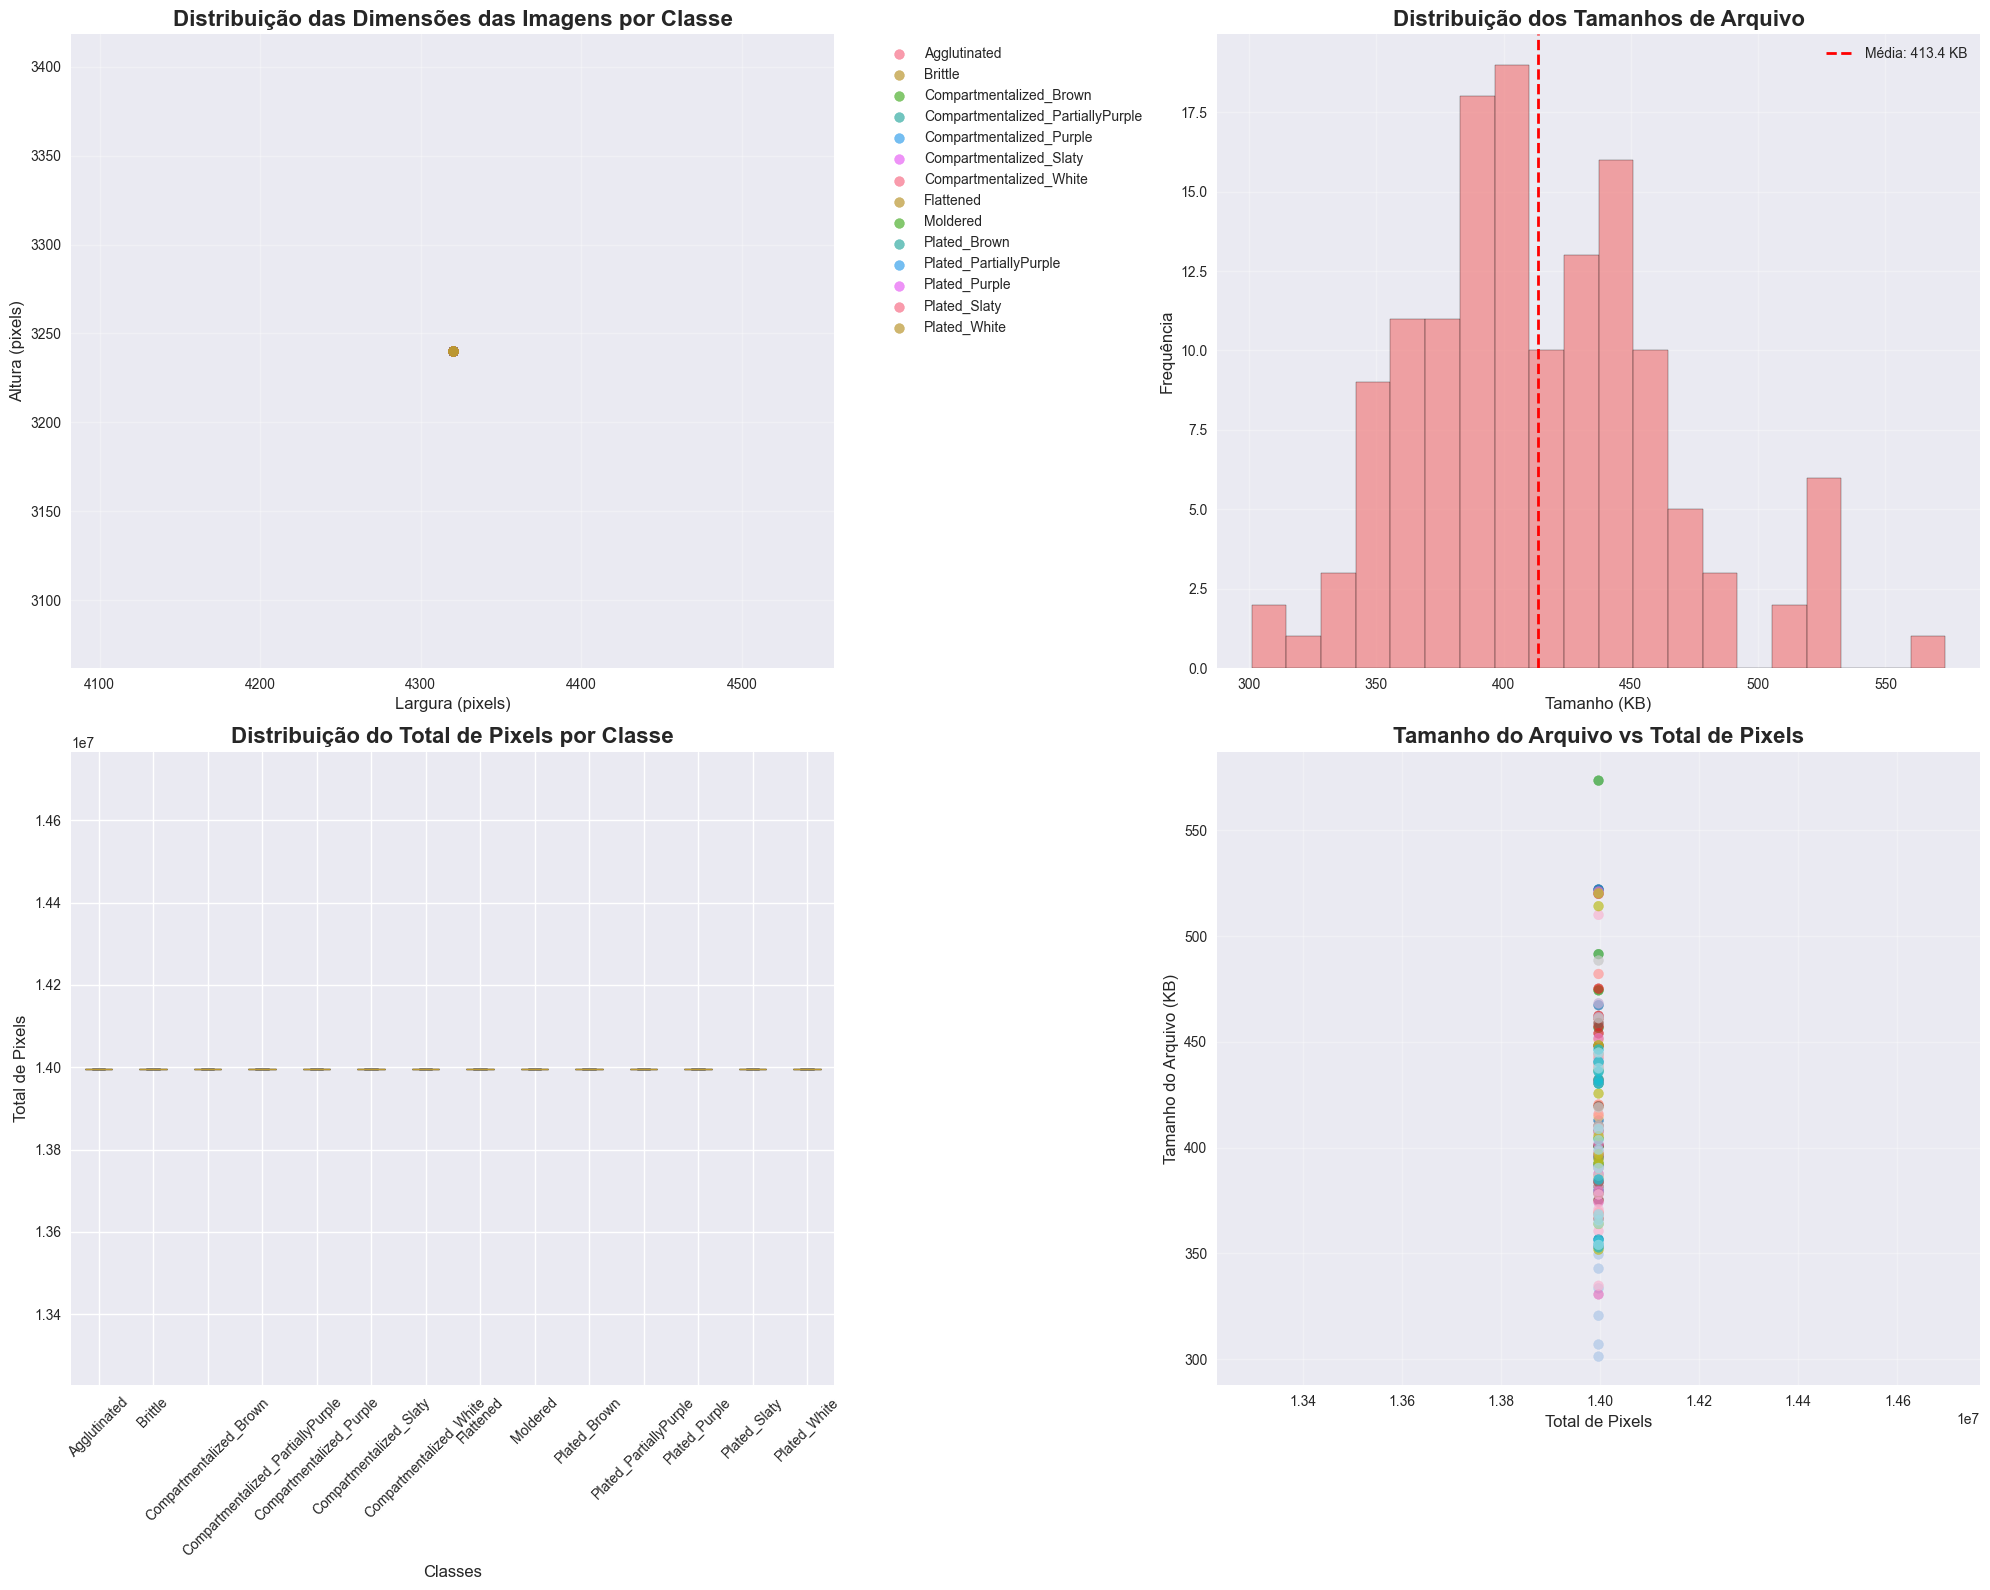

In [31]:
# Análise das propriedades das imagens
print("RESUMO DAS PROPRIEDADES DAS IMAGENS")
print("="*50)

# Estatísticas gerais
print(f"Número de imagens analisadas: {len(valid_images)}")
print(f"Formatos encontrados: {valid_images['format'].value_counts().to_dict()}")
print(f"Modos de cor encontrados: {valid_images['mode'].value_counts().to_dict()}")

print(f"\nDIMENSÕES")
print(f"Largura - Média: {valid_images['width'].mean():.1f}px, Min: {valid_images['width'].min()}px, Max: {valid_images['width'].max()}px")
print(f"Altura - Média: {valid_images['height'].mean():.1f}px, Min: {valid_images['height'].min()}px, Max: {valid_images['height'].max()}px")
print(f"Aspect Ratio - Média: {valid_images['aspect_ratio'].mean():.2f}, Min: {valid_images['aspect_ratio'].min():.2f}, Max: {valid_images['aspect_ratio'].max():.2f}")

print(f"\nTAMANHOS DE ARQUIVO")
print(f"Tamanho médio: {valid_images['file_size_kb'].mean():.1f} KB")
print(f"Tamanho mínimo: {valid_images['file_size_kb'].min():.1f} KB")
print(f"Tamanho máximo: {valid_images['file_size_kb'].max():.1f} KB")
print(f"Tamanho total da amostra: {valid_images['file_size_kb'].sum():.1f} KB")

# Visualizações das propriedades
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1. Distribuição de larguras por classe
for class_name in valid_images['class'].unique():
    class_data = valid_images[valid_images['class'] == class_name]
    ax1.scatter(class_data['width'], class_data['height'], 
               label=class_name, alpha=0.7, s=50)

ax1.set_title('Distribuição das Dimensões das Imagens por Classe', fontsize=16, fontweight='bold')
ax1.set_xlabel('Largura (pixels)', fontsize=12)
ax1.set_ylabel('Altura (pixels)', fontsize=12)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Histograma dos tamanhos de arquivo
ax2.hist(valid_images['file_size_kb'], bins=20, edgecolor='black', alpha=0.7,
         color='lightcoral')
ax2.set_title('Distribuição dos Tamanhos de Arquivo', fontsize=16, fontweight='bold')
ax2.set_xlabel('Tamanho (KB)', fontsize=12)
ax2.set_ylabel('Frequência', fontsize=12)
ax2.grid(True, alpha=0.3)

# Linha vertical para a média
mean_size = valid_images['file_size_kb'].mean()
ax2.axvline(mean_size, color='red', linestyle='--', linewidth=2, 
           label=f'Média: {mean_size:.1f} KB')
ax2.legend()

# 3. Boxplot das dimensões por classe
box_data = [valid_images[valid_images['class'] == class_name]['total_pixels'].values 
           for class_name in valid_images['class'].unique()]
box_labels = valid_images['class'].unique()

box_plot = ax3.boxplot(box_data, labels=box_labels, patch_artist=True)
colors = sns.color_palette("Set3", len(box_labels))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

ax3.set_title('Distribuição do Total de Pixels por Classe', fontsize=16, fontweight='bold')
ax3.set_xlabel('Classes', fontsize=12)
ax3.set_ylabel('Total de Pixels', fontsize=12)
ax3.tick_params(axis='x', rotation=45)

# 4. Scatter plot: Tamanho do arquivo vs Total de pixels
scatter = ax4.scatter(valid_images['total_pixels'], valid_images['file_size_kb'], 
                     c=valid_images['class'].astype('category').cat.codes,
                     cmap='tab20', alpha=0.7, s=50)
ax4.set_title('Tamanho do Arquivo vs Total de Pixels', fontsize=16, fontweight='bold')
ax4.set_xlabel('Total de Pixels', fontsize=12)
ax4.set_ylabel('Tamanho do Arquivo (KB)', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Análise de Métricas de Qualidade das Imagens

In [32]:
# Funções para cálculo de métricas de qualidade da imagem
def calculate_brightness(image_path):
    """Calcular brilho médio da imagem"""
    try:
        img = cv2.imread(str(image_path))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return np.mean(gray)
    except:
        return None

def calculate_contrast(image_path):
    """Calcular contraste da imagem (desvio padrão dos pixels)"""
    try:
        img = cv2.imread(str(image_path))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return np.std(gray)
    except:
        return None

def calculate_sharpness(image_path):
    """Calcular nitidez usando variância do Laplaciano"""
    try:
        img = cv2.imread(str(image_path))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return cv2.Laplacian(gray, cv2.CV_64F).var()
    except:
        return None

# Cálculo de métricas de qualidade para amostra reduzida por performance
print("Calculando métricas de qualidade das imagens...")
print("(Processando 5 imagens por classe para otimização)")

quality_sample_size = 5
quality_metrics = []

for class_name, info in class_info.items():
    print(f"   Processando qualidade - classe: {class_name}")
    
    # Seleção de amostra menor para métricas de qualidade
    sample_files = info['files'][:quality_sample_size] if len(info['files']) >= quality_sample_size else info['files']
    
    for img_path in sample_files:
        brightness = calculate_brightness(img_path)
        contrast = calculate_contrast(img_path)
        sharpness = calculate_sharpness(img_path)
        
        if brightness is not None and contrast is not None and sharpness is not None:
            quality_metrics.append({
                'class': class_name,
                'filename': img_path.name,
                'brightness': brightness,
                'contrast': contrast,
                'sharpness': sharpness
            })

# Conversão para DataFrame
df_quality = pd.DataFrame(quality_metrics)

print(f"\nMétricas de qualidade calculadas para {len(df_quality)} imagens")

Calculando métricas de qualidade das imagens...
(Processando 5 imagens por classe para otimização)
   Processando qualidade - classe: Agglutinated
   Processando qualidade - classe: Brittle
   Processando qualidade - classe: Compartmentalized_Brown
   Processando qualidade - classe: Compartmentalized_PartiallyPurple
   Processando qualidade - classe: Compartmentalized_Purple
   Processando qualidade - classe: Compartmentalized_Slaty
   Processando qualidade - classe: Compartmentalized_White
   Processando qualidade - classe: Flattened
   Processando qualidade - classe: Moldered
   Processando qualidade - classe: Plated_Brown
   Processando qualidade - classe: Plated_PartiallyPurple
   Processando qualidade - classe: Plated_Purple
   Processando qualidade - classe: Plated_Slaty
   Processando qualidade - classe: Plated_White

Métricas de qualidade calculadas para 70 imagens


MÉTRICAS DE QUALIDADE DAS IMAGENS
BRILHO
Médio: 10.22
Mínimo: 4.71
Máximo: 17.68
Desvio padrão: 2.95

CONTRASTE
Médio: 27.71
Mínimo: 19.19
Máximo: 43.23
Desvio padrão: 4.88

NITIDEZ
Média: 34.38
Mínima: 17.81
Máxima: 58.39
Desvio padrão: 9.14

MÉTRICAS POR CLASSE
                                   brightness_mean  brightness_std  contrast_mean  contrast_std  sharpness_mean  sharpness_std
class                                                                                                                         
Agglutinated                                 15.87            2.09          34.01          3.53           29.49           9.02
Brittle                                       5.99            1.19          22.85          1.84           20.62           2.91
Compartmentalized_Brown                      11.12            0.53          27.45          1.68           35.90           2.08
Compartmentalized_PartiallyPurple            12.39            2.36          29.71          3.23      

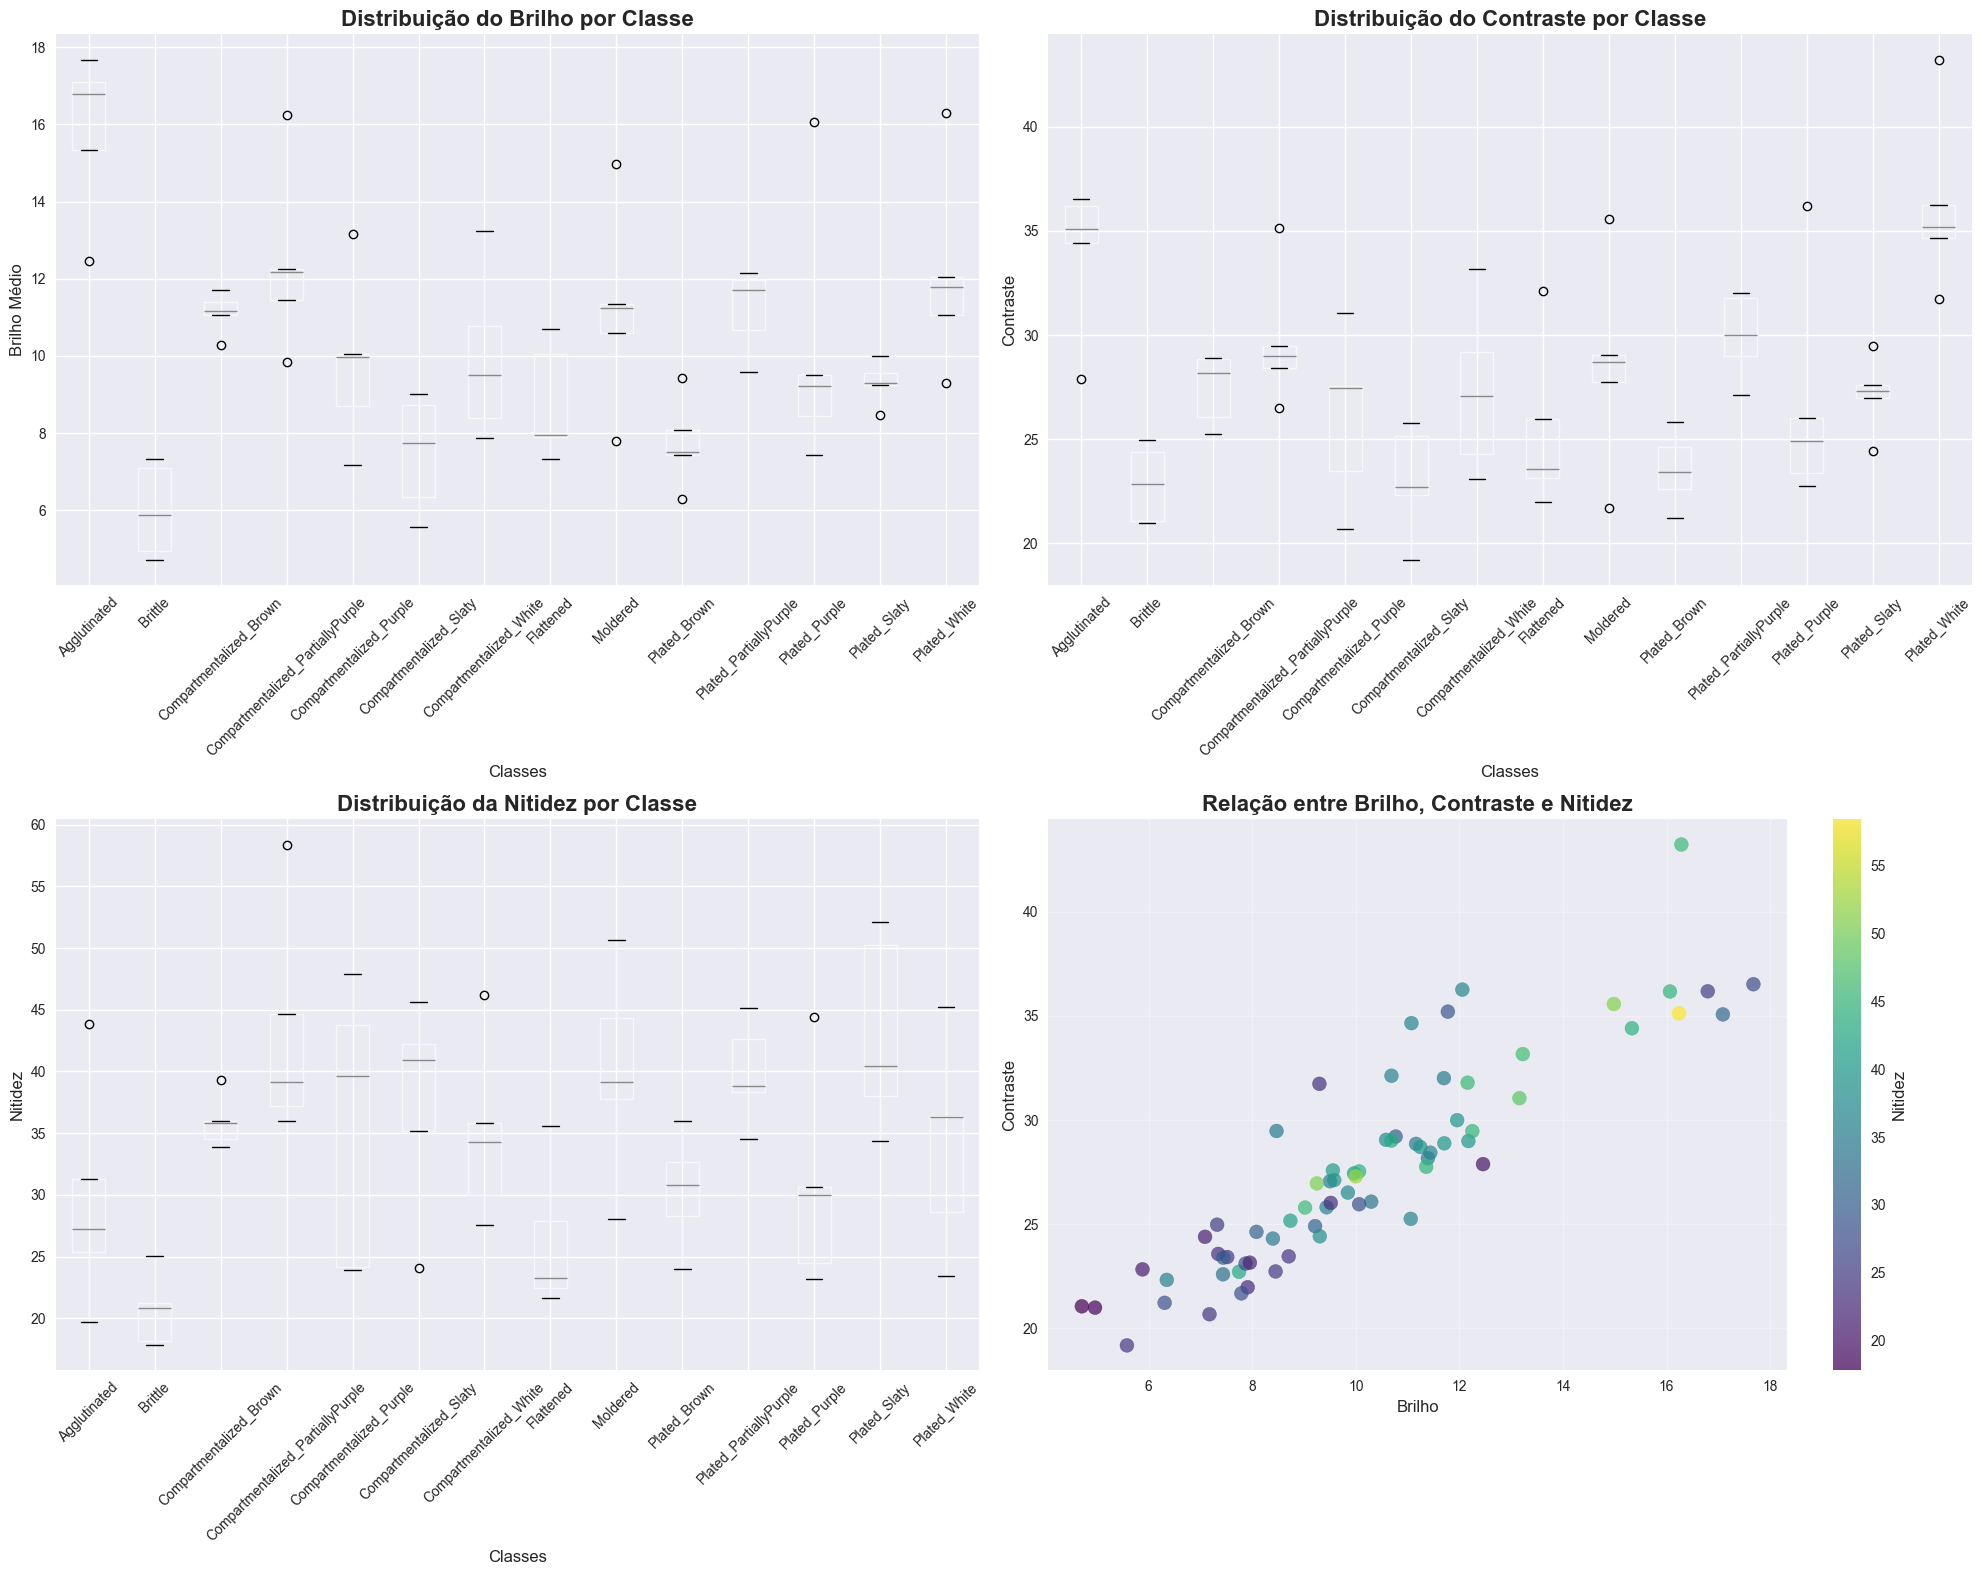


ANÁLISE DE OUTLIERS
Outliers de brilho: 1
Outliers de contraste: 1
Outliers de nitidez: 0
Imagens com brilho anômalo:
       class     filename  brightness
Agglutinated A_002_p7.jpg    17.67724


In [34]:
# Análise das métricas de qualidade
print("MÉTRICAS DE QUALIDADE DAS IMAGENS")
print("="*50)

print(f"BRILHO")
print(f"Médio: {df_quality['brightness'].mean():.2f}")
print(f"Mínimo: {df_quality['brightness'].min():.2f}")
print(f"Máximo: {df_quality['brightness'].max():.2f}")
print(f"Desvio padrão: {df_quality['brightness'].std():.2f}")

print(f"\nCONTRASTE")
print(f"Médio: {df_quality['contrast'].mean():.2f}")
print(f"Mínimo: {df_quality['contrast'].min():.2f}")
print(f"Máximo: {df_quality['contrast'].max():.2f}")
print(f"Desvio padrão: {df_quality['contrast'].std():.2f}")

print(f"\nNITIDEZ")
print(f"Média: {df_quality['sharpness'].mean():.2f}")
print(f"Mínima: {df_quality['sharpness'].min():.2f}")
print(f"Máxima: {df_quality['sharpness'].max():.2f}")
print(f"Desvio padrão: {df_quality['sharpness'].std():.2f}")

# Estatísticas por classe
print(f"\nMÉTRICAS POR CLASSE")
print("="*50)
quality_by_class = df_quality.groupby('class').agg({
    'brightness': ['mean', 'std'],
    'contrast': ['mean', 'std'],
    'sharpness': ['mean', 'std']
}).round(2)

quality_by_class.columns = ['_'.join(col).strip() for col in quality_by_class.columns.values]
print(quality_by_class.to_string())

# Visualizações das métricas de qualidade
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1. Boxplot do brilho por classe
df_quality.boxplot(column='brightness', by='class', ax=ax1)
ax1.set_title('Distribuição do Brilho por Classe', fontsize=16, fontweight='bold')
ax1.set_xlabel('Classes', fontsize=12)
ax1.set_ylabel('Brilho Médio', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 2. Boxplot do contraste por classe
df_quality.boxplot(column='contrast', by='class', ax=ax2)
ax2.set_title('Distribuição do Contraste por Classe', fontsize=16, fontweight='bold')
ax2.set_xlabel('Classes', fontsize=12)
ax2.set_ylabel('Contraste', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

# 3. Boxplot da nitidez por classe
df_quality.boxplot(column='sharpness', by='class', ax=ax3)
ax3.set_title('Distribuição da Nitidez por Classe', fontsize=16, fontweight='bold')
ax3.set_xlabel('Classes', fontsize=12)
ax3.set_ylabel('Nitidez', fontsize=12)
ax3.tick_params(axis='x', rotation=45)

# 4. Scatter plot multivariado
scatter = ax4.scatter(df_quality['brightness'], df_quality['contrast'], 
                     c=df_quality['sharpness'], 
                     cmap='viridis', alpha=0.7, s=100)
ax4.set_title('Relação entre Brilho, Contraste e Nitidez', fontsize=16, fontweight='bold')
ax4.set_xlabel('Brilho', fontsize=12)
ax4.set_ylabel('Contraste', fontsize=12)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Nitidez', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.suptitle('')  # Remove o título automático dos boxplots
plt.tight_layout()
plt.show()

# Identificação de outliers de qualidade
print(f"\nANÁLISE DE OUTLIERS")
print("="*50)

# Definição de thresholds para outliers (Q1 - 1.5*IQR e Q3 + 1.5*IQR)
def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

brightness_outliers = find_outliers(df_quality['brightness'])
contrast_outliers = find_outliers(df_quality['contrast'])
sharpness_outliers = find_outliers(df_quality['sharpness'])

print(f"Outliers de brilho: {len(brightness_outliers)}")
print(f"Outliers de contraste: {len(contrast_outliers)}")
print(f"Outliers de nitidez: {len(sharpness_outliers)}")

if len(brightness_outliers) > 0:
    print("Imagens com brilho anômalo:")
    outlier_indices = brightness_outliers.index
    print(df_quality.loc[outlier_indices, ['class', 'filename', 'brightness']].to_string(index=False))

## 6. Visualização de Amostras por Classe

Visualizando amostras de imagens por classe...


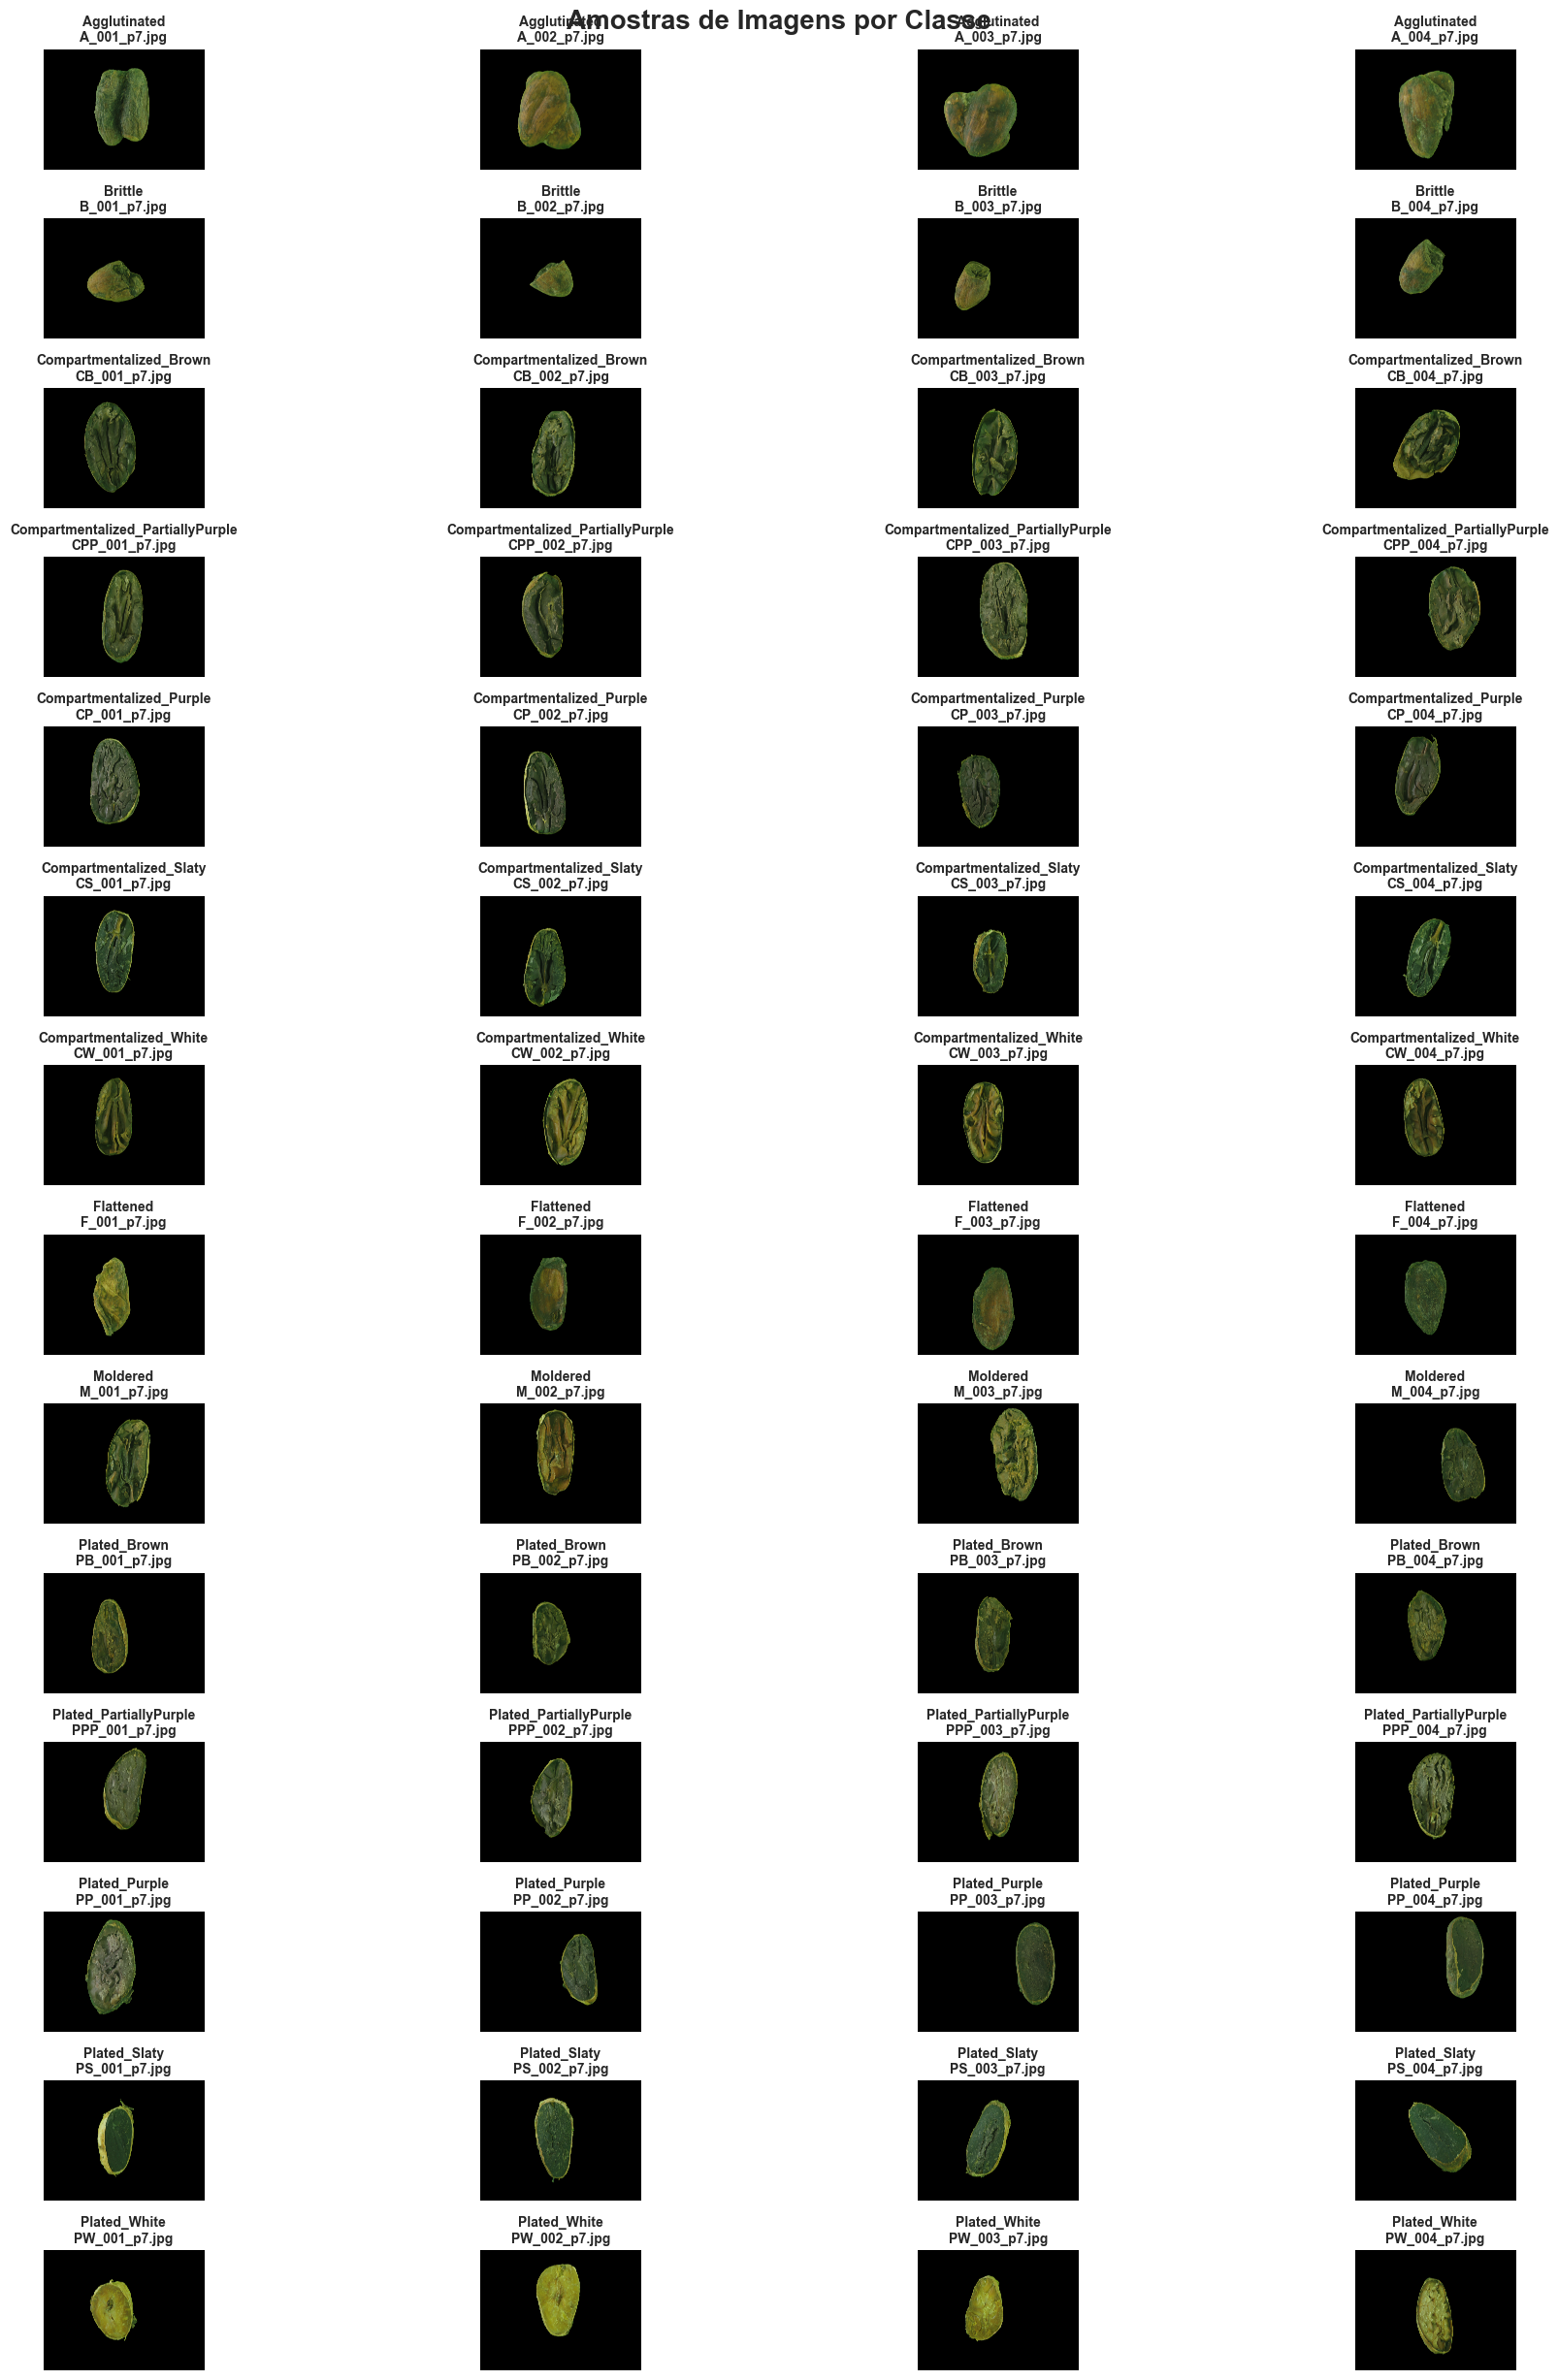

In [35]:
# Função para visualizar amostras de imagens por classe
def show_sample_images_by_class(class_info, samples_per_class=3, figsize=(20, 25)):
    """Exibir amostras de imagens de cada classe"""
    
    num_classes = len(class_info)
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=figsize)
    
    if num_classes == 1:
        axes = axes.reshape(1, -1)
    
    for i, (class_name, info) in enumerate(class_info.items()):
        # Seleção de amostras
        sample_files = info['files'][:samples_per_class] if len(info['files']) >= samples_per_class else info['files']
        
        for j in range(samples_per_class):
            if j < len(sample_files):
                try:
                    # Carregamento e exibição da imagem
                    img = plt.imread(sample_files[j])
                    axes[i, j].imshow(img)
                    axes[i, j].set_title(f'{class_name}\n{sample_files[j].name}', 
                                       fontsize=10, fontweight='bold')
                    axes[i, j].axis('off')
                except Exception as e:
                    axes[i, j].text(0.5, 0.5, f'Erro ao carregar\n{sample_files[j].name}', 
                                  ha='center', va='center', transform=axes[i, j].transAxes)
                    axes[i, j].set_title(f'{class_name} - ERRO', fontsize=10, color='red')
                    axes[i, j].axis('off')
            else:
                # Célula vazia se não há imagens suficientes
                axes[i, j].text(0.5, 0.5, 'Não disponível', 
                              ha='center', va='center', transform=axes[i, j].transAxes)
                axes[i, j].set_title(f'{class_name} - N/A', fontsize=10, color='gray')
                axes[i, j].axis('off')
    
    plt.suptitle('Amostras de Imagens por Classe', fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Exibição de amostras das imagens
print("Visualizando amostras de imagens por classe...")
show_sample_images_by_class(class_info, samples_per_class=4)

Criando visão geral compacta das classes...


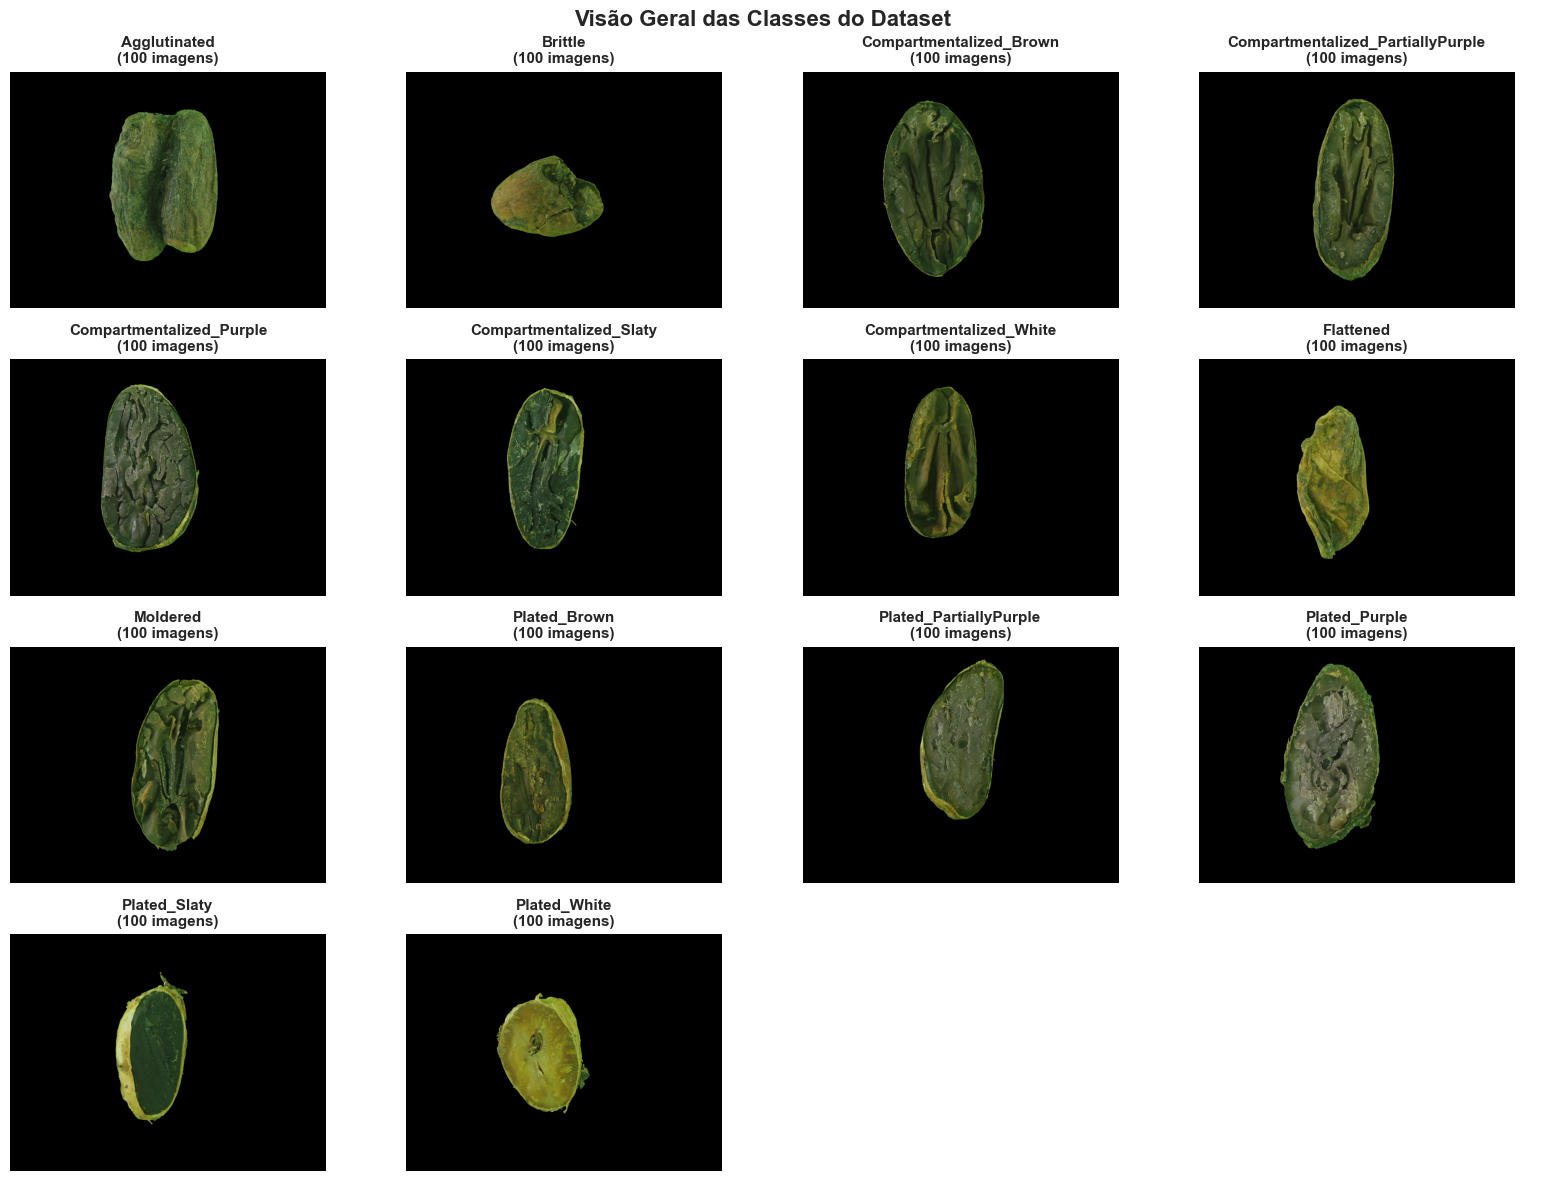

In [26]:
# Criação de visualização compacta com amostra de cada classe
def create_class_overview_grid(class_info, figsize=(16, 12)):
    """Criar grid compacto com imagem representativa de cada classe"""
    
    num_classes = len(class_info)
    cols = 4  # Número de colunas
    rows = (num_classes + cols - 1) // cols  # Cálculo do número de linhas necessárias
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows > 1 else [axes] if num_classes == 1 else axes
    
    for i, (class_name, info) in enumerate(class_info.items()):
        if info['files']:
            try:
                # Carregamento da primeira imagem da classe
                img = plt.imread(info['files'][0])
                axes[i].imshow(img)
                axes[i].set_title(f'{class_name}\n({info["count"]} imagens)', 
                                fontsize=11, fontweight='bold')
                axes[i].axis('off')
            except Exception as e:
                axes[i].text(0.5, 0.5, f'Erro ao carregar\n{class_name}', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(f'{class_name} - ERRO', fontsize=10, color='red')
                axes[i].axis('off')
    
    # Ocultar eixos vazios
    for i in range(num_classes, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Visão Geral das Classes do Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Criando visão geral compacta das classes...")
create_class_overview_grid(class_info)

## 7. Resumo Estatístico Completo

In [30]:
# Geração de resumo estatístico completo
print("RESUMO ESTATÍSTICO COMPLETO DO DATASET")
print("="*80)

# Informações gerais do dataset
print(f"INFORMAÇÕES GERAIS")
print(f"   Total de classes: {len(classes)}")
print(f"   Total de imagens: {total_images:,}")
print(f"   Média de imagens por classe: {total_images/len(classes):.1f}")

# Estatísticas de distribuição
print(f"\nDISTRIBUIÇÃO DAS CLASSES")
max_class = class_distribution.iloc[0]
min_class = class_distribution.iloc[-1]
print(f"   Classe com mais imagens: {max_class['Classe']} ({max_class['Quantidade']} imagens, {max_class['Porcentagem']:.1f}%)")
print(f"   Classe com menos imagens: {min_class['Classe']} ({min_class['Quantidade']} imagens, {min_class['Porcentagem']:.1f}%)")
print(f"   Razão desbalanceamento: {imbalance_ratio:.2f}")

# Estatísticas das propriedades das imagens
if len(valid_images) > 0:
    print(f"\nPROPRIEDADES DAS IMAGENS (Baseado em {len(valid_images)} amostras)")
    print(f"   Dimensões médias: {valid_images['width'].mean():.0f}x{valid_images['height'].mean():.0f} pixels")
    print(f"   Faixa de larguras: {valid_images['width'].min()} - {valid_images['width'].max()} pixels")
    print(f"   Faixa de alturas: {valid_images['height'].min()} - {valid_images['height'].max()} pixels")
    print(f"   Aspect ratio médio: {valid_images['aspect_ratio'].mean():.2f}")
    print(f"   Tamanho médio dos arquivos: {valid_images['file_size_kb'].mean():.1f} KB")
    print(f"   Total de pixels médio: {valid_images['total_pixels'].mean():,.0f}")

# Estatísticas de qualidade
if len(df_quality) > 0:
    print(f"\nMÉTRICAS DE QUALIDADE (Baseado em {len(df_quality)} amostras)")
    print(f"   Brilho médio: {df_quality['brightness'].mean():.1f} ± {df_quality['brightness'].std():.1f}")
    print(f"   Contraste médio: {df_quality['contrast'].mean():.1f} ± {df_quality['contrast'].std():.1f}")
    print(f"   Nitidez média: {df_quality['sharpness'].mean():.1f} ± {df_quality['sharpness'].std():.1f}")

# Criar tabela resumo por classe
summary_table = []

for class_name in classes:
    # Informações básicas
    class_data = {
        'Classe': class_name,
        'Quantidade': class_info[class_name]['count'],
        'Porcentagem': (class_info[class_name]['count'] / total_images * 100)
    }
    
    # Adicionar propriedades se disponível
    if len(valid_images) > 0:
        class_props = valid_images[valid_images['class'] == class_name]
        if len(class_props) > 0:
            class_data['Largura_Media'] = class_props['width'].mean()
            class_data['Altura_Media'] = class_props['height'].mean()
            class_data['Tamanho_KB_Medio'] = class_props['file_size_kb'].mean()
            class_data['Aspect_Ratio'] = class_props['aspect_ratio'].mean()
    
    # Adicionar qualidade se disponível
    if len(df_quality) > 0:
        class_quality = df_quality[df_quality['class'] == class_name]
        if len(class_quality) > 0:
            class_data['Brilho_Medio'] = class_quality['brightness'].mean()
            class_data['Contraste_Medio'] = class_quality['contrast'].mean()
            class_data['Nitidez_Media'] = class_quality['sharpness'].mean()
    
    summary_table.append(class_data)

# Conversão para DataFrame e exibição
summary_df = pd.DataFrame(summary_table)

print(f"\nTABELA RESUMO POR CLASSE")
print("="*80)
print(summary_df.to_string(index=False, float_format='%.1f'))

# Salvamento do resumo em CSV
summary_df.to_csv('../results/dataset_summary.csv', index=False)
print(f"\nResumo salvo em: ../results/dataset_summary.csv")

# Análise final e recomendações
print(f"\nANÁLISE E RECOMENDAÇÕES")
print("="*80)

# Verificação de balanceamento
if imbalance_ratio > 3.0:
    print("AVISO: DATASET SIGNIFICATIVAMENTE DESBALANCEADO")
    print("   Recomendação: Considerar técnicas de balanceamento como:")
    print("     - Data augmentation para classes minoritárias")
    print("     - Weighted loss functions")
    print("     - SMOTE ou oversampling")
elif imbalance_ratio > 2.0:
    print("AVISO: DATASET MODERADAMENTE DESBALANCEADO")
    print("   Recomendação: Monitorar métricas por classe durante o treinamento")
else:
    print("DATASET RELATIVAMENTE BALANCEADO")
    print("   Dataset bem distribuído entre as classes")

# Verificação da qualidade das imagens
if len(df_quality) > 0:
    brightness_cv = df_quality['brightness'].std() / df_quality['brightness'].mean()
    contrast_cv = df_quality['contrast'].std() / df_quality['contrast'].mean()
    
    if brightness_cv > 0.3 or contrast_cv > 0.5:
        print("AVISO: ALTA VARIABILIDADE NA QUALIDADE DAS IMAGENS")
        print("   Recomendação: Considerar normalização de brilho/contraste")
    else:
        print("QUALIDADE DAS IMAGENS CONSISTENTE")

# Verificação de dimensões
if len(valid_images) > 0:
    width_unique = valid_images['width'].nunique()
    height_unique = valid_images['height'].nunique()
    
    if width_unique > 3 or height_unique > 3:
        print("AVISO: MÚLTIPLAS DIMENSÕES DE IMAGEM DETECTADAS")
        print(f"   {width_unique} larguras diferentes, {height_unique} alturas diferentes")
        print("   Recomendação: Redimensionar todas as imagens para tamanho uniforme")
    else:
        print("DIMENSÕES DAS IMAGENS CONSISTENTES")

print(f"\nANÁLISE EXPLORATÓRIA CONCLUÍDA")
print("="*80)

RESUMO ESTATÍSTICO COMPLETO DO DATASET
INFORMAÇÕES GERAIS
   Total de classes: 14
   Total de imagens: 1,400
   Média de imagens por classe: 100.0

DISTRIBUIÇÃO DAS CLASSES
   Classe com mais imagens: Agglutinated (100 imagens, 7.1%)
   Classe com menos imagens: Plated_White (100 imagens, 7.1%)
   Razão desbalanceamento: 1.00

PROPRIEDADES DAS IMAGENS (Baseado em 140 amostras)
   Dimensões médias: 4320x3240 pixels
   Faixa de larguras: 4320 - 4320 pixels
   Faixa de alturas: 3240 - 3240 pixels
   Aspect ratio médio: 1.33
   Tamanho médio dos arquivos: 413.4 KB
   Total de pixels médio: 13,996,800

MÉTRICAS DE QUALIDADE (Baseado em 70 amostras)
   Brilho médio: 10.2 ± 2.9
   Contraste médio: 27.7 ± 4.9
   Nitidez média: 34.4 ± 9.1

TABELA RESUMO POR CLASSE
                           Classe  Quantidade  Porcentagem  Largura_Media  Altura_Media  Tamanho_KB_Medio  Aspect_Ratio  Brilho_Medio  Contraste_Medio  Nitidez_Media
                     Agglutinated         100          7.1         4